# Homework Starter — Stage 10b: Time Series & Classification
Fill in the TODOs. Use your own project dataset or adapt the synthetic generator below.

In [1]:
# --- packages this notebook needs (uncomment and run once, then re-comment) ---
# !pip install numpy
# !pip install pandas
# !pip install seaborn
# !pip install matplotlib
# !pip install scikit-learn

In [2]:
# Imports
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, TimeSeriesSplit
np.random.seed(7); sns.set(); plt.rcParams['figure.figsize']=(9,4)

## Option A: Use Your Project Data (Recommended)
Load your data here (ensure a DateTime index for time series).

In [3]:
import yfinance as yf

# Ingest daily underlying data (SPY or AAPL for your options pricing project)
ticker_symbol = 'SPY'
df_raw = yf.download(ticker_symbol, start='2022-01-01', end='2024-01-01', auto_adjust=True)

# Format into clean 1D Series / DataFrame
df = pd.DataFrame(index=pd.to_datetime(df_raw.index))
df['price'] = df_raw['Close'].values

# Calculate returns
df['ret'] = df['price'].pct_change().fillna(0.0)
df['log_ret'] = np.log1p(df['ret'])

df.head()

[*********************100%***********************]  1 of 1 completed


,price,ret,log_ret
Date,,,
2022-01-03,449.486389,0.000000,0.000000
2022-01-04,449.335938,-0.000335,-0.000335
2022-01-05,440.707672,-0.019202,-0.019389
2022-01-06,440.293640,-0.000939,-0.000940
2022-01-07,438.552979,-0.003953,-0.003961


## Option B: Synthetic Generator (Use if you don't have data ready)

In [ ]:
# # Synthetic series with regimes & jumps
# n=500
# dates=pd.bdate_range('2021-01-01', periods=n)
# mu = np.where(np.arange(n)<n//2, 0.0003, -0.0001)
# sigma = np.where(np.arange(n)<n//2, 0.01, 0.015)
# eps = np.random.normal(mu, sigma)
# jumps = np.zeros(n); jump_days = np.random.choice(np.arange(20,n-20), size=5, replace=False)
# jumps[jump_days] = np.random.normal(0,0.05,size=len(jump_days))
# rets = eps + jumps
# price = 100*np.exp(np.cumsum(rets))
# df = pd.DataFrame({'price':price}, index=dates)
# df['ret'] = df['price'].pct_change().fillna(0.0)
# df['log_ret'] = np.log1p(df['ret'])
# df.head()

## Feature Engineering

In [4]:
# Backward-looking features (avoid lookahead leakage)
df['lag_1'] = df['ret'].shift(1)
df['roll_mean_5'] = df['ret'].rolling(5).mean().shift(1)
df['roll_vol_20'] = df['ret'].rolling(20).std().shift(1)

# Targets
df['y_next_ret'] = df['ret'].shift(-1)              # Forecasting target
df['y_up'] = (df['y_next_ret'] > 0).astype(int)     # Classification target

# Drop rows with NaNs from rolling/shift windows
df_feat = df.dropna().copy()
df_feat.head()

,price,ret,log_ret,lag_1,roll_mean_5,roll_vol_20,y_next_ret,y_up
Date,,,,,,,,
2022-02-01,426.189270,0.006757,0.006734,0.018011,0.004638,0.011616,0.009714,1
2022-02-02,430.329315,0.009714,0.009667,0.006757,0.008431,0.011803,-0.023505,0
2022-02-03,420.214447,-0.023505,-0.023786,0.009714,0.010876,0.012114,0.004702,1
2022-02-04,422.190369,0.004702,0.004691,-0.023505,0.007162,0.012467,-0.003209,0
2022-02-07,420.835480,-0.003209,-0.003214,0.004702,0.003136,0.012563,0.008228,1


## Split

In [5]:
cut = int(len(df_feat) * 0.8)
train, test = df_feat.iloc[:cut], df_feat.iloc[cut:]
features = ['lag_1', 'roll_mean_5', 'roll_vol_20']

X_tr, X_te = train[features], test[features]
y_tr_clf, y_te_clf = train['y_up'], test['y_up']
y_tr_reg, y_te_reg = train['y_next_ret'], test['y_next_ret']

print(f"Train range: {train.index.min().date()} to {train.index.max().date()} ({len(train)} rows)")
print(f"Test range:  {test.index.min().date()} to {test.index.max().date()} ({len(test)} rows)")

Train range: 2022-02-01 to 2023-08-11 (384 rows)
Test range:  2023-08-14 to 2023-12-28 (96 rows)


## Pipeline + Model (Choose one track below)

In [ ]:
# Track 1: Forecasting returns
reg = Pipeline([('scaler', StandardScaler()), ('linreg', LinearRegression())])
reg.fit(X_tr, y_tr_reg)
pred = reg.predict(X_te)
rmse = mean_squared_error(y_te_reg, pred) ** 0.5   # `squared=False` was removed in sklearn >= 1.6
print('RMSE:', rmse)

              precision    recall  f1-score   support

           0       0.35      0.15      0.21        41
           1       0.56      0.80      0.66        55

    accuracy                           0.52        96
   macro avg       0.45      0.47      0.43        96
weighted avg       0.47      0.52      0.46        96



/Users/aaditeya/miniconda3/envs/bootcamp_env/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/aaditeya/miniconda3/envs/bootcamp_env/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/aaditeya/miniconda3/envs/bootcamp_env/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept


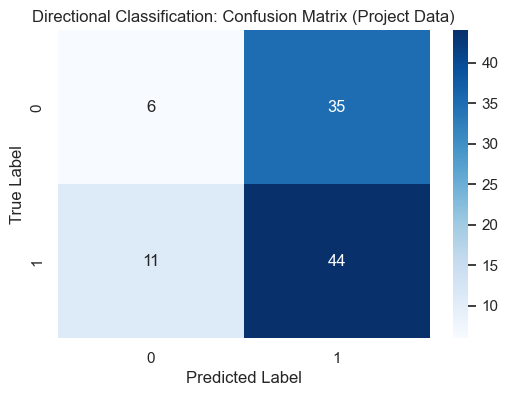

In [7]:
# Track 2: Logistic Directional Classification Pipeline
clf = Pipeline([
    ('scaler', StandardScaler()),
    ('logit', LogisticRegression(max_iter=1000, random_state=7))
])

clf.fit(X_tr, y_tr_clf)
predc = clf.predict(X_te)

print(classification_report(y_te_clf, predc))

cm = confusion_matrix(y_te_clf, predc)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Directional Classification: Confusion Matrix (Project Data)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## Interpretation (Markdown)
- What worked?
- Where might assumptions fail?
- How would you extend features or model?

### Save Notebook
Remember to save as `homework10b_modeling-time-series-and-classification_submission.ipynb`.